###### Flow-Based Subtour Elimination
$$
\begin{aligned}
\min \quad & M \sum_{k \in K} y_k + \sum_{k \in K} \sum_{i \in N} \sum_{\substack{j \in N \\ j \neq i}} d_{ij} U_{ijk} && (1) \\
\text{s.t.} \quad
& \sum_{k \in K} \sum_{\substack{j \in N \\ j \neq i}} U_{ijk} = 1 && \forall i \in C && (2) \\
& \sum_{\substack{j \in N \\ j \neq i}} U_{jik} = \sum_{\substack{j \in N \\ j \neq i}} U_{ijk} && \forall i \in N, \; k \in K && (3) \\
& \sum_{j \in C} U_{0jk} = y_k && \forall k \in K && (4) \\
& \sum_{i \in C} U_{i0k} = y_k && \forall k \in K && (5) \\
& \sum_{i \in N} \sum_{\substack{j \in N \\ j \neq i}} d_{ij} U_{ijk} \le D_{max} \cdot y_k && \forall k \in K && (6) \\
& \sum_{\substack{j \in N \\ j \neq i}} F_{ji} - \sum_{\substack{j \in N \\ j \neq i}} F_{ij} = 1 && \forall i \in C && (7) \\
& \sum_{j \in C} F_{0j} - \sum_{i \in C} F_{i0} = |C| && && (8) \\
& F_{ij} \le |C| \sum_{k \in K} U_{ijk} && \forall i, j \in N, \; i \neq j && (9) \\
& U_{ijk} \in \{0,1\}, \; y_k \in \{0,1\}, \; F_{ij} \ge 0 && \forall i,j \in N, \; i \neq j, \; k \in K && (10)
\end{aligned}
$$

---
| Ref | Description |
| --- | --- |
| (1) | Minimize the number of activated vehicles first (using big coefficient $M$), then minimize the total travel distance |
| (2) | Each customer is visited exactly once |
| (3) | Flow conservation: inflow equals outflow for each vehicle at every node |
| (4) | An activated vehicle must start from the depot |
| (5) | An activated vehicle must return to the depot |
| (6) | Total distance traveled by each vehicle cannot exceed $D_{max}$ |
| (7) | Each customer consumes 1 unit of flow (subtour elimination) |
| (8) | The depot supplies a net flow equal to the number of customers |
| (9) | Flow can only pass through edges that are traversed by at least one vehicle |
| (10) | Binary and non-negativity variable domains |


In [54]:
depot = 0

customers = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]

nodes = [depot] + customers

vehicles = [0, 1, 2, 3]

max_distance = 30

distance = [
    #   0   1   2   3   4   5   6   7   8   9  10
    [  0,  6,  9,  7,  8, 10,  5, 11,  8,  9, 12],  # 0 Depot
    [  6,  0,  4,  6,  7,  5,  8,  9,  6,  7, 10],  # 1
    [  9,  4,  0,  5,  6,  7,  9,  8,  7,  6,  9],  # 2
    [  7,  6,  5,  0,  4,  6,  7,  9,  5,  8, 10],  # 3
    [  8,  7,  6,  4,  0,  5,  6,  8,  7,  9, 11],  # 4
    [ 10, 5,  7,  6,  5,  0,  4,  7,  6,  8, 10],  # 5
    [  5, 8,  9,  7,  6,  4,  0,  6,  5,  7,  9],  # 6
    [ 11, 9,  8,  9,  8,  7,  6,  0,  5,  6,  8],  # 7
    [  8, 6,  7,  5,  7,  6,  5,  5,  0,  4,  7],  # 8
    [  9, 7,  6,  8,  9,  8,  7,  6,  4,  0,  5],  # 9
    [ 12,10,  9, 10, 11, 10,  9,  8,  7,  5,  0],  # 10
]

In [58]:
from ortools.sat.python import cp_model

In [59]:
model = cp_model.CpModel()


u_ijk = {}
f_ij = {}
y_k = {}
for i in nodes:
    for j in nodes:
        if i != j:
            for k in vehicles:
                    u_ijk[i,j,k] = model.NewBoolVar(f"u[{i},{j},{k}]")
            f_ij[i,j] = model.NewIntVar(0, len(customers), f"f[{i},{j}]")
    
for k in vehicles:
    y_k[k] = model.NewBoolVar(f"y[{k}]")


 
for i in customers:
    model.Add(sum(
       [u_ijk[i,j,k]  for j in nodes for k in vehicles if j!=i]) == 1)


    
for i in nodes:
    for k in vehicles:
        input_lst = [u_ijk[j,i,k] for j in nodes if j!=i]
        output_lst = [u_ijk[i,j,k] for j in nodes if j!=i]
        model.Add(sum(input_lst) == sum(output_lst))


        
for k in vehicles: 
    model.Add(sum([u_ijk[depot, j, k] for j in customers]) == y_k[k])
    model.Add(sum([u_ijk[i, depot, k] for i in customers]) == y_k[k])

    model.Add(
        sum(
            [distance[i][j]*u_ijk[i,j,k] 
            for i in nodes for j in nodes if i != j] ) <= max_distance*y_k[k] )

    
for i in customers:
    inflow = sum([f_ij[j,i] for j in nodes if j!= i])
    outflow = sum([f_ij[i,j] for j in nodes if j!=i])
    model.Add(
        inflow - outflow == 1
    )

model.Add(
sum(f_ij[depot, j] for j in customers)
-
sum(f_ij[i, depot] for i in customers)
== len(customers)
)
for i in nodes:
    for j in nodes:
        if j != i:
            model.Add(
                f_ij[i,j] <= len(customers) * sum([u_ijk[i,j,k] for k in vehicles])
            )
        
            
# model.Minimize(sum(y_k[k] for k in vehicles))

model.Minimize(
    1000* sum(y_k[k] for k in vehicles)
    +
    sum(
        distance[i][j] * u_ijk[i,j,k]
        for i in nodes
        for j in nodes
        if i != j
        for k in vehicles
)
)

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 200.0
status = solver.Solve(model)

print(status)


# for k in vehicles:
#     for i in nodes:
#         for j in nodes:
#             if i != j:
#                 if solver.Value(u_ijk[i,j,k]) != 0:
#                     print(f"u[{i},{j},{k}]", solver.Value(u_ijk[i,j,k]))
#     print(solver.Value(y_k[k]))

CpSolverStatus.OPTIMAL


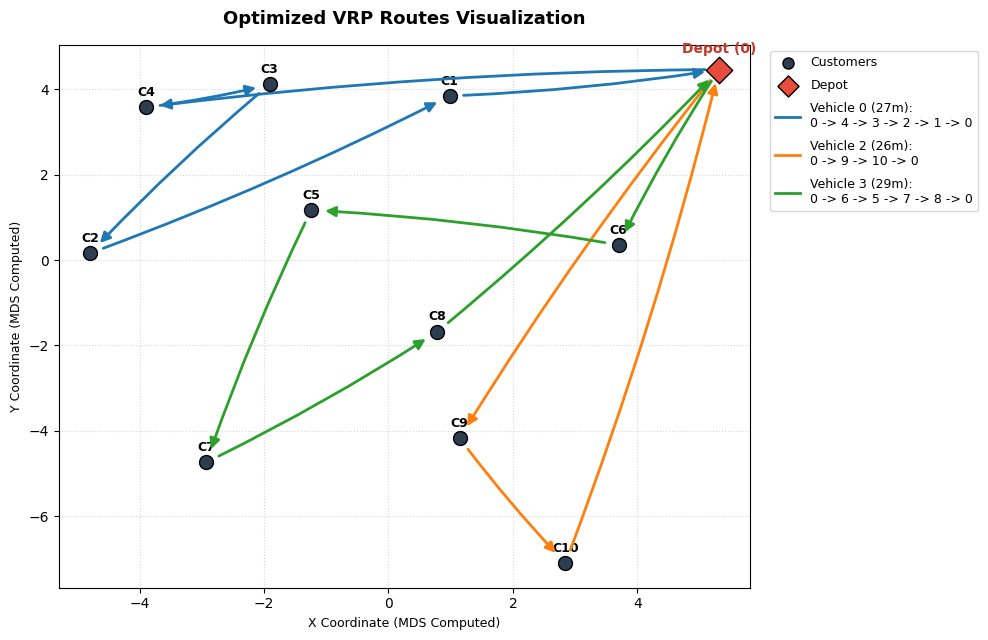

In [60]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    metric='precomputed',
    init='random',
    normalized_stress='auto',
    random_state=42
)
coords_2d = mds.fit_transform(np.array(distance))
node_coords = {node: (coords_2d[node, 0], coords_2d[node, 1]) for node in nodes}

routes = {}
for k in vehicles:
    if solver.Value(y_k[k]) == 1:
        edges = []
        for i in nodes:
            for j in nodes:
                if i != j and solver.Value(u_ijk[i, j, k]) == 1:
                    edges.append((i, j))
        if edges:
            ordered_route = []
            curr_node = depot
            while edges:
                for edge in edges:
                    if edge[0] == curr_node:
                        ordered_route.append(edge)
                        curr_node = edge[1]
                        edges.remove(edge)
                        break
            routes[k] = ordered_route

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=100)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

x_cust = [node_coords[i][0] for i in customers]
y_cust = [node_coords[i][1] for i in customers]
ax.scatter(x_cust, y_cust, color="#2c3e50", s=100, zorder=4, label="Customers", edgecolors="black")

ax.scatter(
    node_coords[depot][0],
    node_coords[depot][1],
    color="#e74c3c",
    s=180,
    marker="D",
    zorder=5,
    label="Depot",
    edgecolors="black"
)

ax.annotate(
    "Depot (0)",
    node_coords[depot],
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    weight="bold",
    fontsize=10,
    color="#c0392b"
)

for c in customers:
    ax.annotate(
        f"C{c}",
        node_coords[c],
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        weight="bold",
        fontsize=9
    )

for idx, (k, edges) in enumerate(routes.items()):
    c = colors[idx % len(colors)]
    route_dist = sum(distance[i][j] for i, j in edges)
    route_nodes = [str(depot)] + [str(j) for _, j in edges]
    path_str = " -> ".join(route_nodes)
    legend_label = f"Vehicle {k} ({route_dist}m):\n{path_str}"

    ax.plot([], [], color=c, label=legend_label, linewidth=2)

    for start, end in edges:
        x1, y1 = node_coords[start]
        x2, y2 = node_coords[end]
        
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="-|>",
                color=c,
                lw=2,
                mutation_scale=15,
                shrinkA=10,
                shrinkB=10,
                connectionstyle="arc3,rad=0.03"  # کمان بسیار ملایم
            ),
            zorder=3
        )

ax.set_title("Optimized VRP Routes Visualization", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("X Coordinate (MDS Computed)", fontsize=9)
ax.set_ylabel("Y Coordinate (MDS Computed)", fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#cccccc",
    markerscale=0.8,
    labelspacing=0.8,
    fontsize=9
)

plt.tight_layout()
plt.show()